In [4]:
import pandas as pd
import numpy as np

# ============================================
# Load California Housing Dataset
# ============================================
try:
    url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
    df = pd.read_csv(url)
    print("Dataset loaded successfully from URL!")

except Exception:
    print("URL download failed.")
    print("Generating synthetic dataset...")

    np.random.seed(42)
    n_samples = 5000

    df = pd.DataFrame({
        "longitude": np.random.uniform(-124.5, -114.5, n_samples),
        "latitude": np.random.uniform(32.5, 42.0, n_samples),
        "housing_median_age": np.random.randint(1, 52, n_samples),
        "total_rooms": np.random.normal(2000, 1000, n_samples).astype(int),
        "total_bedrooms": np.random.normal(500, 250, n_samples).astype(int),
        "population": np.random.normal(1200, 800, n_samples).astype(int),
        "households": np.random.normal(450, 250, n_samples).astype(int),
        "median_income": np.random.uniform(0.5, 15, n_samples),
        "median_house_value": np.random.normal(200000, 80000, n_samples).astype(int),
        "ocean_proximity": np.random.choice(
            [
                "NEAR BAY",
                "<1H OCEAN",
                "INLAND",
                "NEAR OCEAN",
                "ISLAND"
            ],
            n_samples,
            p=[0.30, 0.30, 0.30, 0.09, 0.01]
        )
    })

    # Create a relationship between features and house price
    df["median_house_value"] = (
        df["median_income"] * 40000 +
        df["housing_median_age"] * 1000 +
        df["total_rooms"] * 20 +
        np.random.normal(0, 30000, n_samples)
    ).astype(int)

# Limit house values to realistic values
df["median_house_value"] = df["median_house_value"].clip(
    lower=50000,
    upper=500001
)

print("Dataset created successfully!")

Dataset loaded successfully from URL!
Dataset created successfully!


In [5]:
# Independent variable (X)
X = df[['median_income']]
# Target variable (y)
y = df['median_house_value']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)


In [7]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 16512
Test set size: 4128


In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")

Intercept : 44665.46
Coefficient : 41897.32


In [11]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)
print(train_rmse)
print(test_rmse)
print(train_r2)
print(test_r2)


83555.4732840986
84125.73950971125
0.4769125447043495
0.458833707595123


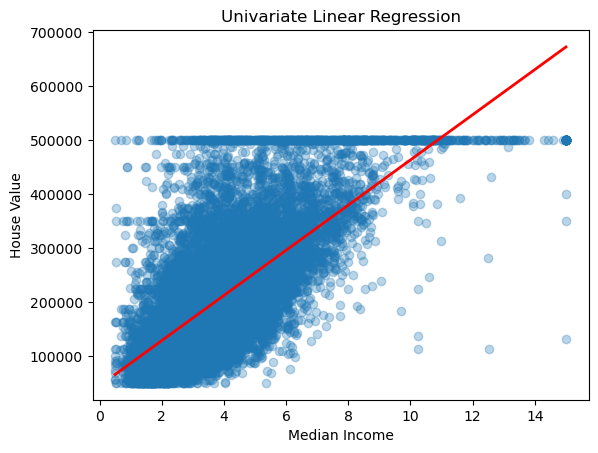

In [13]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train, alpha=0.3)
X_sorted = X_train.sort_values("median_income")
y_sorted = model.predict(X_sorted)
plt.plot(
X_sorted,
y_sorted,
color="red",
linewidth=2
)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Univariate Linear Regression")
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["ocean_proximity_encoded"] = encoder.fit_transform(
df["ocean_proximity"]
)

In [15]:
features = [
"median_income",
"housing_median_age",
"total_rooms",
"total_bedrooms",
"population",
"households",
"latitude",
"longitude",
"ocean_proximity_encoded"
]
X = df[features]
y = df["median_house_value"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
